In [8]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


# **TRANSFORMS**

In [9]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

dataset = torchvision.datasets.CIFAR100(
    root='./data', train=True, download=True, transform=train_transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

test_dataset = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True, transform=test_transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

100%|██████████| 169M/169M [00:05<00:00, 29.6MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


# Why normalization must match ImageNet?

*   ResNet50 was pretrained on ImageNet.
*   Convolution filters expect inputs centered using ImageNet statistics.
*   Mismatch shifts activation distributions and reduces transfer efficiency.

# Why augmentation improves generalization?

*   CIFAR-100 has limited resolution and class imbalance.
*   Augmentation increases data diversity.
*   Encourages invariance to spatial distortions.
*   Reduces overfitting during fine-grained learning.

# **Feature** **Extraction**

In [10]:
import torch.nn as nn
import torchvision.models as models

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
num_classes = 100

model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
)

# He Initialization
for m in model.modules():
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s]


# **Why He Initialization?**

*   ReLU discards negative activations.
*   He initialization preserves forward variance.
*   Prevents vanishing/exploding gradients.
*   Especially important when training only the new classifier head.

In [11]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4  # L2 regularization
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

In [12]:
import copy

best_val_loss = float('inf')
patience = 5
counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

In [ ]:
num_epochs = 5

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / len(train_loader.dataset)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()
    val_loss, val_correct = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / len(val_loader.dataset)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

model.load_state_dict(best_model_wts)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [14]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

NameError: name 'train_loss' is not defined

# Why early stopping is critical here?

*   CIFAR-100 is fine-grained → easier to overfit.
*   Transfer learning converges rapidly.
*   Prevents memorization of small-scale patterns.

# Why weight decay is important?

*   CIFAR-100 has 100 classes → high classifier complexity.
*   L2 penalizes large weights.
*   Encourages smoother decision boundaries.

In [ ]:
for name, param in model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-4
)

In [4]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
print(cm)

print(classification_report(all_labels, all_preds))

NameError: name 'model' is not defined

### Load and Display an Image

First, let's load an image using OpenCV. You can replace `image_path` with the path to your desired image.

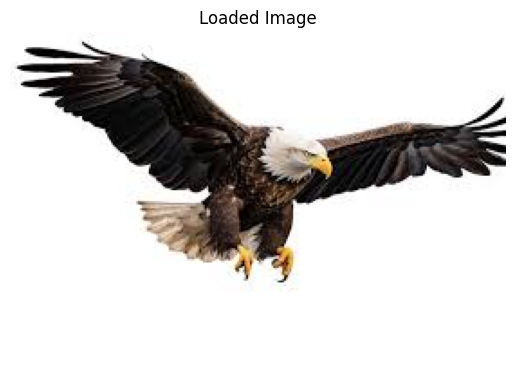

In [2]:
import cv2
import matplotlib.pyplot as plt
import os

# NOTE: Replace 'path/to/your/image.jpg' with the actual path to your image file from your workspace.
# For example: image_path = '/content/my_image.jpg'
image_path = '/content/eagle.jpg' # <--- REPLACE THIS WITH YOUR IMAGE PATH

img = None
if image_path and os.path.exists(image_path):
    # Load the image
    img = cv2.imread(image_path)

    if img is not None:
        # OpenCV loads images in BGR format, matplotlib expects RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Display the image
        plt.imshow(img_rgb)
        plt.title('Loaded Image')
        plt.axis('off')
        plt.show()
    else:
        print(f"Error: Could not load image from {image_path}. Please check the file path and integrity.")
else:
    print(f"No image path provided or file does not exist at {image_path}. Please set a valid `image_path`.")

### Predict the Class of the Image

Now, let's preprocess the loaded image and use our trained model to predict its class.

In [3]:
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt

if 'img' in locals() and img is not None:
    # Convert OpenCV image (numpy array) to PIL Image for torchvision transforms
    pil_img = Image.fromarray(img_rgb)

    # Apply the same test transform as used for the dataset
    # Ensure test_transform is defined (it was in cell jJlqVx6UBL82)
    processed_img = test_transform(pil_img)

    # Add a batch dimension (BCHW format) and move to device
    processed_img = processed_img.unsqueeze(0).to(device)

    # Set model to evaluation mode
    model.eval()

    with torch.no_grad():
        outputs = model(processed_img)
        probabilities = torch.softmax(outputs, dim=1)
        predicted_prob, predicted_idx = torch.max(probabilities, 1)

    # CIFAR-100 has 100 classes. We need a way to map index to class name.
    # Let's assume you have a list of class names, e.g., from torchvision.datasets.CIFAR100
    # The CIFAR100 dataset provides a 'classes' attribute.

    # You might need to re-initialize CIFAR100 dataset to get class names if they aren't directly available.
    try:
        # Attempt to get class names from the existing dataset object
        class_names = dataset.classes # Assuming 'dataset' is the CIFAR100 training dataset
    except NameError:
        # If dataset is not in scope, re-load a small dummy dataset to get class names
        dummy_dataset = torchvision.datasets.CIFAR100(root='./data', train=True, download=False) # download=False as it should be downloaded
        class_names = dummy_dataset.classes

    predicted_class_name = class_names[predicted_idx.item()]

    print(f"Predicted class index: {predicted_idx.item()}")
    print(f"Predicted class name: {predicted_class_name}")
    print(f"Prediction confidence: {predicted_prob.item():.4f}")

    # --- Add text to image and display ---
    # Make a copy to draw on, as img_rgb might be used elsewhere
    img_with_text = img_rgb.copy()

    # Define text properties
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1
    font_thickness = 2
    text_color = (255, 255, 255) # White color in RGB
    background_color = (0, 0, 0) # Black background for readability

    # Get text size for background rectangle
    text1 = f"Class: {predicted_class_name}"
    text2 = f"Confidence: {predicted_prob.item():.2f}"

    (text1_width, text1_height), baseline1 = cv2.getTextSize(text1, font, font_scale, font_thickness)
    (text2_width, text2_height), baseline2 = cv2.getTextSize(text2, font, font_scale, font_thickness)

    # Position the text at the top-left corner
    x_offset = 10
    y_offset = 30

    # Draw background rectangle for first line
    cv2.rectangle(img_with_text, (x_offset, y_offset - text1_height - baseline1),
                  (x_offset + text1_width, y_offset + baseline1), background_color, -1)
    # Put the first text on the image
    cv2.putText(img_with_text, text1, (x_offset, y_offset), font, font_scale, text_color, font_thickness, cv2.LINE_AA)

    # Adjust y_offset for the second line
    y_offset += text1_height + 10 # Add some padding

    # Draw background rectangle for second line
    cv2.rectangle(img_with_text, (x_offset, y_offset - text2_height - baseline2),
                  (x_offset + text2_width, y_offset + baseline2), background_color, -1)
    # Put the second text on the image
    cv2.putText(img_with_text, text2, (x_offset, y_offset), font, font_scale, text_color, font_thickness, cv2.LINE_AA)

    # Display the image with the prediction
    plt.figure(figsize=(8, 8))
    plt.imshow(img_with_text)
    plt.title('Image with Predicted Class')
    plt.axis('off')
    plt.show()

else:
    print("Cannot classify: No image was loaded successfully.")


NameError: name 'test_transform' is not defined